# 01 · Data Profiling & Quality Check

**Goal:** before analysing anything, understand what's in the data and what's wrong with it.
Real analysts always start here — bad data gives confident-looking wrong answers.

**How to use this notebook:** run each cell with **Shift + Enter**, read the output, then read the note below it.
Every SQL keyword is explained the first time it appears.

## Setup
We connect Python to the DuckDB database built by `src/load_data.py`.
`sql()` is a tiny helper: give it a SQL query as text, it returns the result as a table (a pandas *DataFrame*).

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

DB_PATH = Path("..") / "data" / "olist.duckdb"   # ".." = go up one folder from notebooks/
con = duckdb.connect(str(DB_PATH), read_only=True)

def sql(query):
    """Run a SQL query and return the result as a pandas DataFrame."""
    return con.sql(query).df()

print("Connected!")

Connected!


## 1. What tables do we have?
`information_schema.tables` is a built-in table that lists every table in the database.

In [2]:
sql("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    ORDER BY table_name
""")

,table_schema,table_name
0,raw,category_translation
1,raw,customers
2,raw,geolocation
3,raw,order_items
4,raw,order_payments
5,raw,order_reviews
6,raw,orders
7,raw,products
8,raw,sellers


## 2. Look at the data: `SELECT`, `FROM`, `LIMIT`
- **SELECT** = which columns you want (`*` means all of them)
- **FROM** = which table
- **LIMIT** = only show the first N rows (always do this on big tables)

In [3]:
sql("SELECT * FROM raw.orders LIMIT 5")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


Each row is **one order**. Note the 5 timestamps — purchase → approved → handed to carrier → delivered → *estimated* delivery.
We'll compare *delivered* vs *estimated* later to measure late deliveries.

`DESCRIBE` shows each column's data type (VARCHAR = text, TIMESTAMP = date+time, BIGINT/DOUBLE = numbers):

In [4]:
sql("DESCRIBE raw.orders")[["column_name", "column_type"]]

,column_name,column_type
0,order_id,VARCHAR
1,customer_id,VARCHAR
2,order_status,VARCHAR
3,order_purchase_timestamp,TIMESTAMP
4,order_approved_at,TIMESTAMP
5,order_delivered_carrier_date,TIMESTAMP
6,order_delivered_customer_date,TIMESTAMP
7,order_estimated_delivery_date,TIMESTAMP


## 3. Counting: `COUNT(*)` and `COUNT(DISTINCT ...)`
- `COUNT(*)` counts rows
- `COUNT(DISTINCT col)` counts **unique** values
- `AS` gives a result column a readable name

If rows = unique order IDs, each order appears exactly once (no duplicates).

In [5]:
sql("""
    SELECT COUNT(*)                 AS total_rows,
           COUNT(DISTINCT order_id) AS unique_orders
    FROM raw.orders
""")

,total_rows,unique_orders
0,99441,99441


## 4. Grouping: `GROUP BY` and `ORDER BY`
**GROUP BY** squashes rows into groups and lets you count/sum each group — the most-used idea in analytics.
**ORDER BY ... DESC** sorts largest first. `ROUND(x, 2)` rounds to 2 decimals.

In [6]:
sql("""
    SELECT order_status,
           COUNT(*) AS orders,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM raw.orders
    GROUP BY order_status
    ORDER BY orders DESC
""")

,order_status,orders,pct_of_total
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


**Finding:** ~97% of orders are `delivered`. For revenue and delivery analysis we'll mostly use delivered orders,
and treat `canceled` / `unavailable` separately.

*(The `SUM(COUNT(*)) OVER ()` part is a **window function** — it gives the grand total so we can compute a percentage. We'll learn these properly on Day 3.)*

## 5. Date range & orders per month
`MIN` / `MAX` give the earliest/latest value. `strftime(timestamp, '%Y-%m')` turns a timestamp into text like `2017-11` so we can group by month.

In [7]:
sql("""
    SELECT MIN(order_purchase_timestamp) AS first_order,
           MAX(order_purchase_timestamp) AS last_order
    FROM raw.orders
""")

,first_order,last_order
0,2016-09-04 21:15:19,2018-10-17 17:30:18


,month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


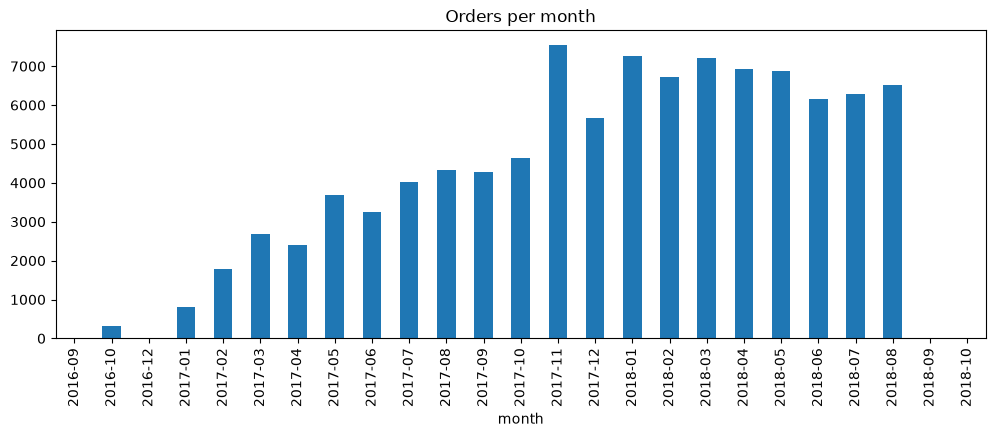

In [8]:
monthly = sql("""
    SELECT strftime(order_purchase_timestamp, '%Y-%m') AS month,
           COUNT(*) AS orders
    FROM raw.orders
    GROUP BY month
    ORDER BY month
""")
monthly.plot(x="month", y="orders", kind="bar", figsize=(12, 4), legend=False, title="Orders per month")
monthly

**Finding:** 2016 has only a handful of orders (Sept, Oct, one in Dec) and Sept–Oct 2018 has almost none — the dataset starts and ends mid-stream.
If we include those months, trend charts show fake "crashes". **Decision: analyse Jan 2017 – Aug 2018 (20 full months).**
Also notice the **Nov 2017 spike** → Black Friday.

## 6. Missing values (NULLs)
`COUNT(col)` counts only **non-null** values, so `COUNT(*) - COUNT(col)` = number of missing values.

In [9]:
sql("""
    SELECT COUNT(*) - COUNT(order_approved_at)             AS missing_approved,
           COUNT(*) - COUNT(order_delivered_carrier_date)  AS missing_carrier,
           COUNT(*) - COUNT(order_delivered_customer_date) AS missing_delivered
    FROM raw.orders
""")

,missing_approved,missing_carrier,missing_delivered
0,160,1783,2965


Most missing delivery dates are expected — canceled or still-shipping orders were never delivered. But are there **delivered** orders with no delivery date?
**WHERE** filters rows *before* anything is counted. `IS NULL` checks for missing values (you can't write `= NULL`).

In [10]:
sql("""
    SELECT COUNT(*) AS delivered_but_no_date
    FROM raw.orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NULL
""")

,delivered_but_no_date
0,8


**Finding:** a few delivered orders have no delivery date — a genuine data error. Tiny number, so we'll exclude them from delivery-time analysis and note it.

## 7. ⚠️ The customer_id trap
In the customers table there are two ID columns. Let's count unique values of each.

In [11]:
sql("""
    SELECT COUNT(*)                           AS rows,
           COUNT(DISTINCT customer_id)        AS unique_customer_id,
           COUNT(DISTINCT customer_unique_id) AS unique_customer_unique_id
    FROM raw.customers
""")

,rows,unique_customer_id,unique_customer_unique_id
0,99441,99441,96096


**Finding:** `customer_id` is unique on **every row** — Olist creates a new one for **each order**.
The real person is `customer_unique_id`. If we measured repeat customers with `customer_id`, *everyone* would look like a one-time buyer.

How many real people ordered more than once? **HAVING** filters *groups* (after GROUP BY), whereas WHERE filters *rows*.
A query inside brackets is a **subquery** — we count the rows it returns.

In [12]:
sql("""
    SELECT COUNT(*) AS repeat_customers,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(DISTINCT customer_unique_id) FROM raw.customers), 2) AS pct_repeat
    FROM (
        SELECT customer_unique_id
        FROM raw.customers
        GROUP BY customer_unique_id
        HAVING COUNT(*) > 1
    )
""")

,repeat_customers,pct_repeat
0,2997,3.12


**Finding (headline!):** only about **3%** of customers ever came back. Retention is Olist's big business problem — we dig into this on Day 4.

## 8. Duplicates in reviews
If each order had exactly one review, rows = unique review IDs = unique order IDs. Let's check.

In [13]:
sql("""
    SELECT COUNT(*)                  AS rows,
           COUNT(DISTINCT review_id) AS unique_reviews,
           COUNT(DISTINCT order_id)  AS unique_orders
    FROM raw.order_reviews
""")

,rows,unique_reviews,unique_orders
0,99224,98410,98673


In [14]:
sql("""
    SELECT COUNT(*) AS orders_with_multiple_reviews
    FROM (
        SELECT order_id FROM raw.order_reviews
        GROUP BY order_id
        HAVING COUNT(*) > 1
    )
""")

,orders_with_multiple_reviews
0,547


**Finding:** some orders have more than one review, and some review IDs repeat. If we join reviews to orders as-is, those orders get **double-counted**.
**Decision:** keep only the latest review per order when we build clean tables (Day 2).

## 9. Geolocation: many rows per zip code

In [15]:
sql("""
    SELECT COUNT(*)                                     AS rows,
           COUNT(DISTINCT geolocation_zip_code_prefix)  AS unique_zip_prefixes,
           ROUND(COUNT(*) / COUNT(DISTINCT geolocation_zip_code_prefix), 1) AS avg_rows_per_zip
    FROM raw.geolocation
""")

,rows,unique_zip_prefixes,avg_rows_per_zip
0,1000163,19015,52.6


**Finding:** ~1M rows but only ~19k zip prefixes (~50 rows each). Joining this directly would multiply our orders ~50×!
**Decision:** use **state** for geography (already in customers/sellers). If we need a map, average lat/lng per zip first.

## 10. Products: missing & untranslated categories
A **LEFT JOIN** keeps every row from the left table, even when there's no match on the right (the right side becomes NULL).
That makes it perfect for finding things that *don't* match.

In [16]:
sql("""
    SELECT COUNT(*) - COUNT(product_category_name) AS products_missing_category
    FROM raw.products
""")

,products_missing_category
0,610


In [17]:
sql("""
    SELECT DISTINCT p.product_category_name AS untranslated_category
    FROM raw.products AS p
    LEFT JOIN raw.category_translation AS t
           ON p.product_category_name = t.product_category_name
    WHERE t.product_category_name IS NULL
      AND p.product_category_name IS NOT NULL
""")

,untranslated_category
0,pc_gamer
1,portateis_cozinha_e_preparadores_de_alimentos


**Finding:** ~610 products have no category (we'll label them `unknown`), and 2 Portuguese categories are missing from the translation table (we'll translate them by hand).

## 11. Orders with no items

In [18]:
sql("""
    SELECT o.order_status, COUNT(*) AS orders_without_items
    FROM raw.orders AS o
    LEFT JOIN raw.order_items AS i ON o.order_id = i.order_id
    WHERE i.order_id IS NULL
    GROUP BY o.order_status
    ORDER BY orders_without_items DESC
""")

,order_status,orders_without_items
0,unavailable,603
1,canceled,164
2,created,5
3,invoiced,2
4,shipped,1


**Finding:** these are almost all canceled/unavailable orders — no revenue, so they naturally drop out of revenue analysis.

## 12. Payment types

In [19]:
sql("""
    SELECT payment_type, COUNT(*) AS payments
    FROM raw.order_payments
    GROUP BY payment_type
    ORDER BY payments DESC
""")

,payment_type,payments
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


**Finding:** credit card dominates (~74%), then boleto (a Brazilian bank slip). 3 rows are `not_defined` — we'll exclude them.

---
## ✏️ Your turn (5 minutes — this is how SQL sticks)
Write these yourself in the empty cells below. Answers are in `LEARNING_NOTES.md` — try first!
1. How many sellers are there in each state? Which state has the most?
2. What's the average `review_score`? (hint: `AVG()`)
3. How many orders were placed in November 2017? (hint: `WHERE strftime(...) = '2017-11'`)

In [ ]:
# 1. sellers per state

In [ ]:
# 2. average review score

In [ ]:
# 3. orders in Nov 2017

---
## Summary of data quality findings
| # | Issue | Impact | Decision |
|---|---|---|---|
| 1 | Sparse data in 2016 and Sep–Oct 2018 | Fake trend drops | Analyse Jan 2017 – Aug 2018 |
| 2 | `customer_id` is per-order | Retention would look like 0% | Use `customer_unique_id` for people |
| 3 | Duplicate reviews per order | Double counting | Keep latest review per order |
| 4 | ~50 geolocation rows per zip | Row explosion on joins | Use state; aggregate zips if mapping |
| 5 | Delivered orders missing delivery date | Wrong delivery times | Exclude from delivery metrics |
| 6 | Products with no / untranslated category | Gaps in category charts | Label `unknown`, translate 2 manually |
| 7 | 3 payments with type `not_defined` | Noise | Exclude |

Full write-up: `reports/data_quality_report.md`. Next (Day 2): build clean tables and the star schema.

In [20]:
con.close()